# Chapter 1 - Introduction to Machine Learning

Bab ini membahas konsep dasar Machine Learning, jenis permasalahan, serta implementasi awal menggunakan dataset Iris.

## Why Machine Learning?

Pendekatan berbasis aturan memiliki keterbatasan untuk masalah kompleks.

Machine Learning memungkinkan sistem belajar langsung dari data dan melakukan prediksi tanpa aturan eksplisit.

Keunggulan:
- Adaptif terhadap data
- Dapat menangani data kompleks
- Tidak perlu aturan manual

## Types of Machine Learning

### Supervised Learning
- Data memiliki label
- Contoh: klasifikasi dan regresi

### Unsupervised Learning
- Data tanpa label
- Contoh: clustering dan anomaly detection

## Knowing Your Data

Sebelum membuat model, penting untuk memahami:
- Struktur data
- Fitur yang digunakan
- Tujuan analisis


## A First Application: Iris Dataset

Dataset Iris digunakan untuk klasifikasi jenis bunga berdasarkan 4 fitur:
- Sepal length
- Sepal width
- Petal length
- Petal width

In [10]:
# =========================
# IMPORT LIBRARY
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [11]:
# =========================
# LOAD DATASET (OFFLINE)
# =========================
iris = load_iris()

iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target

iris_df['species'] = iris_df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

print(iris_df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [12]:
# =========================
# DATA VALIDATION
# =========================
print(iris_df.info())
print(iris_df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


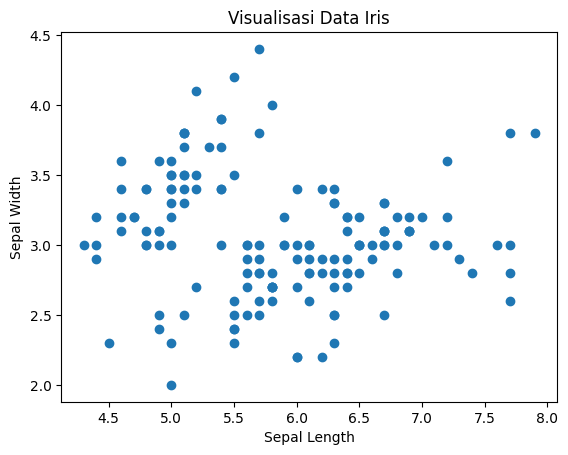

In [13]:
# =========================
# VISUALISASI SEDERHANA
# =========================
plt.scatter(iris_df['sepal length (cm)'], iris_df['sepal width (cm)'])
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Visualisasi Data Iris')
plt.show()


## Train-Test Split

Data dibagi menjadi data training dan testing untuk mengukur kemampuan generalisasi model.

In [14]:
X = iris_df.drop('species', axis=1)
y = iris_df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)


(120, 4) (30, 4)


## Model: K-Nearest Neighbors

KNN bekerja dengan mencari tetangga terdekat dan menentukan kelas berdasarkan mayoritas.

In [15]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=3)

## Evaluasi Model

Model dievaluasi menggunakan accuracy, classification report, dan confusion matrix.

In [16]:
y_pred = model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


## Prediksi Data Baru

Model dapat digunakan untuk memprediksi data yang belum pernah dilihat.

In [17]:
sample = np.array([[5.1, 3.5, 1.4, 0.2]])
prediction = model.predict(sample)

print('Hasil prediksi:', prediction[0])


Hasil prediksi: setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


## Conclusion

- Machine Learning memungkinkan sistem belajar dari data
- Model harus diuji dengan data baru
- KNN merupakan algoritma sederhana untuk klasifikasi
